Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 132ms/step - accuracy: 0.4264 - loss: 1.0617 - val_accuracy: 0.6316 - val_loss: 0.9149
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6661 - loss: 0.9042 - val_accuracy: 0.8421 - val_loss: 0.7805
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8445 - loss: 0.7563 - val_accuracy: 0.8947 - val_loss: 0.6663
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9266 - loss: 0.6607 - val_accuracy: 0.8947 - val_loss: 0.5733
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9544 - loss: 0.5599 - val_accuracy: 0.8947 - val_loss: 0.4929
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9565 - loss: 0.4411 - val_accuracy: 0.9474 - val_loss: 0.4237
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9638 - loss: 0.3950 - val_accuracy: 0.9211 - val_loss: 0.3646
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9768 - loss: 0.3155 - val_accuracy: 0.8947 - val_loss: 0.3156

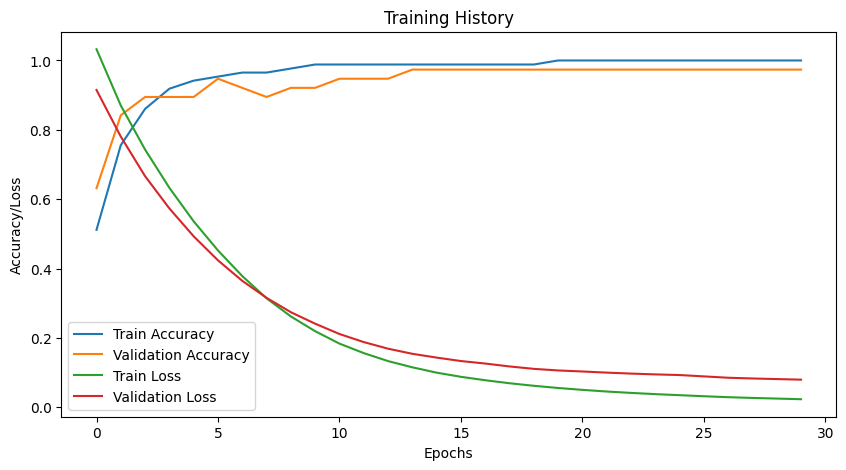

In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical
from ucimlrepo import fetch_ucirepo 
  
wine = fetch_ucirepo(id=109) 
  

X = wine.data.features 
y = wine.data.targets 
  
scaler = StandardScaler()
X = scaler.fit_transform(X)

encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(np.array(y).reshape(-1, 1))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = Sequential([
    Input(shape=(X_train.shape[1],)),  # Define input shape
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(y_train.shape[1], activation='softmax')  # Output layer
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=30, batch_size=16, validation_split=0.3, verbose=1)

loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.2f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Accuracy/Loss')
plt.legend()
plt.title('Training History')
plt.show()
